# Complementary Learning Systems (CLS) DGEqProp Extension Demo

This notebook demonstrates and benchmarks the two-memory **Complementary Learning Systems (CLS)** architecture (`CLSDGEqPropNetwork`) against the standard `DGEqPropSequenceNetwork` and `GPT2SequenceModel` on a catastrophic forgetting benchmark.

The CLS model separates memory into:
1. **Hippocampal store (HPC)**: fast learning rate, immediate encoding (e.g. 5 epochs).
2. **Neocortical store (CTX)**: slow learning rate, consolidated gradually via offline replay.

We analyze:
- **Online-only vs consolidated recall**
- **Consolidation cycle sweep**
- **Retrieval blend alpha sweep**
- **Side-by-side comparison** against baseline models

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from memval.encoders import SymbolicEncoder, SymbolicDecoder
from memval.models.baselines import GPT2SequenceModel, DGEqPropSequenceNetwork, CLSDGEqPropNetwork

sns.set_theme(style='darkgrid')

def mean_recall_rate(recall_curve):
    return float(np.mean(recall_curve[1:]))

def memory_span(recall_curve, threshold=0.75):
    span = 0
    for r in recall_curve[1:]:
        if r >= threshold:
            span += 1
        else:
            break
    return span

def measure_recall_threshold(network, words, encoder, decoder, context_vec=None, n_trials=30, noise_scale=0.05, **kwargs):
    success_counts = np.zeros(len(words))
    success_counts[0] = n_trials
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        network.reset_context()
        for i in range(len(words) - 1):
            network.current_t = i
            noisy_evt = encoder.encode([words[i]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
            raw_pred = network.predict_next(noisy_evt, current_context=context, **kwargs)
            pred_word = decoder.decode(raw_pred, top_k=1)[0]
            if pred_word == words[i + 1]:
                success_counts[i + 1] += 1
    return success_counts / n_trials

def measure_recall_autoregressive(network, words, encoder, decoder, context_vec=None, n_trials=30, noise_scale=0.05, **kwargs):
    success_counts = np.zeros(len(words))
    success_counts[0] = n_trials
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        network.reset_context()
        current_evt = encoder.encode([words[0]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
        for i in range(len(words) - 1):
            raw_pred = network.predict_next(current_evt, current_context=context, **kwargs)
            pred_word = decoder.decode(raw_pred, top_k=1)[0]
            if pred_word == words[i + 1]:
                success_counts[i + 1] += 1
            current_evt = network.decode_prediction(raw_pred)
    return success_counts / n_trials

def recall_fidelity(network, words, encoder, context_vec=None, n_trials=30, noise_scale=0.05, **kwargs):
    gt_embs = encoder.encode(words)
    total_sim, count = 0.0, 0
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        network.reset_context()
        for i in range(len(words) - 1):
            network.current_t = i
            noisy = encoder.encode([words[i]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
            pred = network.predict_next(noisy, current_context=context, **kwargs)
            sim = float(pred @ gt_embs[i + 1]) / (np.linalg.norm(pred) * np.linalg.norm(gt_embs[i + 1]) + 1e-8)
            total_sim += sim
            count += 1
    return total_sim / count

## Setup Catastrophic Forgetting Benchmark
We define a vocabulary and three sequential lists (fruits, animals, cars) with corresponding context vectors.

In [2]:
vocab_multi = {
    'apple': 'fruit', 'banana': 'fruit', 'orange': 'fruit', 'grape': 'fruit', 'pear': 'fruit',
    'dog': 'animal', 'cat': 'animal', 'horse': 'animal', 'cow': 'animal', 'sheep': 'animal',
    'ford': 'car', 'chevy': 'car', 'dodge': 'car', 'toyota': 'car', 'honda': 'car'
}
encoder_multi = SymbolicEncoder(vocab_multi, embedding_dim=100, category_variance=0.2, seed=42)
decoder_multi = SymbolicDecoder(encoder_multi)

lists = {
    'fruits': ['apple', 'banana', 'orange', 'grape', 'pear'],
    'animals': ['dog', 'cat', 'horse', 'cow', 'sheep'],
    'cars': ['ford', 'chevy', 'dodge', 'toyota', 'honda']
}
rng = np.random.default_rng(42)
context_map = {
    'fruits':  rng.integers(0, 2, size=32).astype(float),
    'animals': rng.integers(0, 2, size=32).astype(float),
    'cars':    rng.integers(0, 2, size=32).astype(float),
}
n_trials = 30

## 1. Online-Only vs Consolidated Recall
We train the model sequentially on all three categories. We evaluate the recall of each category *before* consolidation (HPC only) and *after* consolidation (CTX only).

In [ ]:
# Initialize CLS DGEqProp model
cls_net = CLSDGEqPropNetwork(
    n_features=100,
    n_context=0,
    n_explicit=1,
    n_dg=1000,
    n_hidden=128,
    learning_rate=0.1,
    hpc_epochs=5,
    ctx_epochs=100,
    ctx_lr_scale=0.1,
    max_buffer_size=10,
    auto_consolidate=False, # We trigger consolidation manually to compare
    seed=42
)

# Train sequentially
for cat, words in lists.items():
    enc_words = encoder_multi.encode(words)
    context_seq = np.tile(context_map[cat], (len(words), 1))
    cls_net.fit_sequence(enc_words, context_seq)

# Measure recall before consolidation (HPC only, alpha=1.0)
mrr_before = {}
for cat, words in lists.items():
    curve = measure_recall_threshold(cls_net, words, encoder_multi, decoder_multi, context_map[cat], n_trials=n_trials, blend_alpha=1.0)
    mrr_before[cat] = mean_recall_rate(curve)

# Consolidate neocortex
cls_net.consolidate(n_cycles=15)

# Measure recall after consolidation (CTX only, alpha=0.0)
mrr_after = {}
for cat, words in lists.items():
    curve = measure_recall_threshold(cls_net, words, encoder_multi, decoder_multi, context_map[cat], n_trials=n_trials, blend_alpha=0.0)
    mrr_after[cat] = mean_recall_rate(curve)

print("--- Online-Only (HPC) vs. Consolidated (CTX) Recall MRR ---")
print(f"{'Category':<12} | {'Online (HPC)':<15} | {'Consolidated (CTX)':<18}")
print("-" * 50)
for cat in lists.keys():
    print(f"{cat:<12} | {mrr_before[cat]:<15.3f} | {mrr_after[cat]:<18.3f}")

## 2. Consolidation Cycle Sweep
We vary the number of consolidation cycles (`n_cycles` = 0, 1, 5, 15, 30) and track neocortical recall improvement vs hippocampal forgetting.

In [ ]:
cycles = [0, 1, 5, 15, 30]
ctx_mrr_history = []
hpc_mrr_history = []

for c in cycles:
    # Reinitialize model to train clean
    model_sweep = CLSDGEqPropNetwork(
        n_features=100,
        n_context=32,
        n_dg=1000,
        n_hidden=128,
        learning_rate=0.05,
        hpc_epochs=5,
        ctx_epochs=100,
        ctx_lr_scale=0.1,
        max_buffer_size=10,
        auto_consolidate=False,
        seed=42
)
    for cat, words in lists.items():
        enc_words = encoder_multi.encode(words)
        context_seq = np.tile(context_map[cat], (len(words), 1))
        model_sweep.fit_sequence(enc_words, context_seq)
        
    if c > 0:
        model_sweep.consolidate(n_cycles=c)
        
    # Measure average MRR across all categories for CTX (alpha=0.0) and HPC (alpha=1.0)
    ctx_mrrs = [mean_recall_rate(measure_recall_threshold(model_sweep, w, encoder_multi, decoder_multi, context_map[cat], n_trials=10, blend_alpha=0.0)) for cat, w in lists.items()]
    hpc_mrrs = [mean_recall_rate(measure_recall_threshold(model_sweep, w, encoder_multi, decoder_multi, context_map[cat], n_trials=10, blend_alpha=1.0)) for cat, w in lists.items()]
    
    ctx_mrr_history.append(np.mean(ctx_mrrs))
    hpc_mrr_history.append(np.mean(hpc_mrrs))

plt.figure(figsize=(10, 5))
plt.plot(cycles, ctx_mrr_history, '-o', label='Neocortex (Slow, CTX)', color='royalblue', linewidth=2)
plt.plot(cycles, hpc_mrr_history, '-s', label='Hippocampus (Fast, HPC)', color='crimson', linewidth=2)
plt.title("Consolidation Sweep: Neocortical Learning vs. Hippocampal Forgetting")
plt.xlabel("Consolidation Cycles")
plt.ylabel("Mean Recall Rate (MRR)")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Retrieval Blend Alpha Sweep
We sweep `blend_alpha` from 0.0 (pure neocortex) to 1.0 (pure hippocampus) on a fully consolidated model. We plot average MRR, Word Span, and Recall Fidelity.

In [ ]:
# Initialize and train/consolidate a model
model_blend = CLSDGEqPropNetwork(
    n_features=100,
    n_context=32,
    n_dg=1000,
    n_hidden=128,
    learning_rate=0.05,
    hpc_epochs=5,
    ctx_epochs=100,
    ctx_lr_scale=0.1,
    max_buffer_size=10,
    auto_consolidate=False,
    seed=42
)
for cat, words in lists.items():
    enc_words = encoder_multi.encode(words)
    context_seq = np.tile(context_map[cat], (len(words), 1))
    model_blend.fit_sequence(enc_words, context_seq)
model_blend.consolidate(n_cycles=15)

alphas = np.linspace(0.0, 1.0, 6)
mrrs = []
spans = []
fidelities = []

for a in alphas:
    alpha_mrrs = []
    alpha_spans = []
    alpha_fids = []
    for cat, words in lists.items():
        curve_assoc = measure_recall_threshold(model_blend, words, encoder_multi, decoder_multi, context_map[cat], n_trials=10, blend_alpha=a)
        curve_auto = measure_recall_autoregressive(model_blend, words, encoder_multi, decoder_multi, context_map[cat], n_trials=10, blend_alpha=a)
        fid = recall_fidelity(model_blend, words, encoder_multi, context_vec=context_map[cat], n_trials=10, blend_alpha=a)
        
        alpha_mrrs.append(mean_recall_rate(curve_assoc))
        alpha_spans.append(memory_span(curve_auto))
        alpha_fids.append(fid)
        
    mrrs.append(np.mean(alpha_mrrs))
    spans.append(np.mean(alpha_spans))
    fidelities.append(np.mean(alpha_fids))

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Blend Alpha (HPC strength)')
ax1.set_ylabel('Mean Recall Rate & Fidelity', color=color)
ax1.plot(alphas, mrrs, '-o', label='MRR', color='royalblue')
ax1.plot(alphas, fidelities, '-x', label='Recall Fidelity', color='teal')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(-0.05, 1.05)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Memory Span (words)', color=color)  
ax2.plot(alphas, spans, '-s', label='Memory Span', color='crimson')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 5)
ax2.legend(loc='upper right')

plt.title("Blend Alpha Sweep: Hippocampal-Neocortical Retrieval Trade-off")
fig.tight_layout()  
plt.show()

## 3.5 Simple Pattern Completion (Single 5-item List)
We benchmark pattern completion of a single 5-item sequence using various blend alpha retrieval configs. This measures basic working memory retrieval dynamics in isolation.

Training CLS network on a single 5-item list...


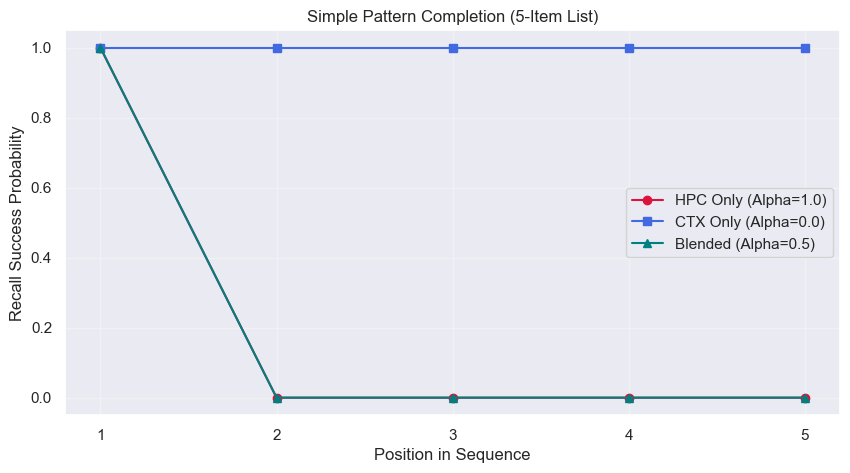

HPC Only MRR: 0.000
CTX Only MRR: 1.000
Blended MRR: 0.000


In [26]:
# Train CLS network on a single 5-item list
print("Training CLS network on a single 5-item list...")
single_list = ['apple', 'banana', 'orange', 'grape', 'pear']
enc_single = encoder_multi.encode(single_list)
context_single = np.tile(context_map['fruits'], (len(single_list), 1))

model_simple = CLSDGEqPropNetwork(
    n_features=100,
    n_context=0,
    n_explicit=1,
    n_dg=1000,
    learning_rate=0.5,
    hpc_epochs=50,
    ctx_epochs=100,
    ctx_lr_scale=0.25,
    max_buffer_size=10,
    auto_consolidate=False,
    seed=42
)

# Fit single sequence (online only)
model_simple.fit_sequence(enc_single, context_single)

# HPC-only (Alpha=1.0) before consolidation
curve_hpc_only = measure_recall_threshold(model_simple, single_list, encoder_multi, decoder_multi, context_map['fruits'], blend_alpha=1.0)

# Consolidate
model_simple.consolidate(n_cycles=20)

# CTX-only (Alpha=0.0) and Blended (Alpha=0.5) post-consolidation
curve_ctx_only = measure_recall_threshold(model_simple, single_list, encoder_multi, decoder_multi, context_map['fruits'], blend_alpha=0.0)
curve_blended = measure_recall_threshold(model_simple, single_list, encoder_multi, decoder_multi, context_map['fruits'], blend_alpha=0.5)

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(single_list) + 1), curve_hpc_only, '-o', label='HPC Only (Alpha=1.0)', color='crimson')
plt.plot(range(1, len(single_list) + 1), curve_ctx_only, '-s', label='CTX Only (Alpha=0.0)', color='royalblue')
plt.plot(range(1, len(single_list) + 1), curve_blended, '-^', label='Blended (Alpha=0.5)', color='teal')
plt.title("Simple Pattern Completion (5-Item List)")
plt.xlabel("Position in Sequence")
plt.ylabel("Recall Success Probability")
plt.xticks(range(1, len(single_list) + 1))
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"HPC Only MRR: {mean_recall_rate(curve_hpc_only):.3f}")
print(f"CTX Only MRR: {mean_recall_rate(curve_ctx_only):.3f}")
print(f"Blended MRR: {mean_recall_rate(curve_blended):.3f}")


## 4. Side-by-Side Model Comparison on Catastrophic Forgetting
We compare the consolidated `CLSDGEqPropNetwork` against standard `DGEqPropSequenceNetwork` (online sequential only, no replay) and `GPT2SequenceModel` (sequential fine-tuning, no replay) on our catastrophic forgetting benchmark.

In [ ]:
# 1. Train standard DGEqProp
print("Training standard DGEqProp model sequentially...")
dg_net = DGEqPropSequenceNetwork(
    n_features=100,
    n_context=32,
    n_dg=1000,
    n_hidden=128,
    learning_rate=0.05,
    seed=42,
    n_epochs=100
)
for cat, words in lists.items():
    enc_words = encoder_multi.encode(words)
    context_seq = np.tile(context_map[cat], (len(words), 1))
    dg_net.fit_sequence(enc_words, context_seq)

# 2. Train GPT-2 Sequence model
print("Training GPT2SequenceModel sequentially...")
gpt_net = GPT2SequenceModel(
    encoder=encoder_multi,
    n_epochs=100,
    device="cpu"
)
for cat, words in lists.items():
    enc_words = encoder_multi.encode(words)
    context_seq = np.tile(context_map[cat], (len(words), 1))
    gpt_net.fit_sequence(enc_words, context_seq)

# Measure final MRR for all models
results = {
    'CLS DGEqProp (Consolidated)': [],
    'DGEqProp (Online-only)': [],
    'GPT-2 (Sequential FT)': []
}

for cat, words in lists.items():
    # CLS (alpha=0.0)
    curve_cls = measure_recall_threshold(model_blend, words, encoder_multi, decoder_multi, context_map[cat], n_trials=n_trials, blend_alpha=0.0)
    results['CLS DGEqProp (Consolidated)'].append(mean_recall_rate(curve_cls))
    
    # Standard DG-EqProp
    curve_dg = measure_recall_threshold(dg_net, words, encoder_multi, decoder_multi, context_map[cat], n_trials=n_trials)
    results['DGEqProp (Online-only)'].append(mean_recall_rate(curve_dg))
    
    # GPT-2
    curve_gpt = measure_recall_threshold(gpt_net, words, encoder_multi, decoder_multi, context_map[cat], n_trials=n_trials)
    results['GPT-2 (Sequential FT)'].append(mean_recall_rate(curve_gpt))

# Plot comparative bar chart
x = np.arange(len(lists))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width, results['CLS DGEqProp (Consolidated)'], width, label='CLS DGEqProp (Consolidated)', color='#2ecc71')
rects2 = ax.bar(x, results['DGEqProp (Online-only)'], width, label='DGEqProp (Online-only)', color='#e74c3c')
rects3 = ax.bar(x + width, results['GPT-2 (Sequential FT)'], width, label='GPT-2 (Sequential FT)', color='#3498db')

ax.set_ylabel('Mean Recall Rate (MRR)')
ax.set_title('Catastrophic Forgetting Benchmark: Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(lists.keys())
ax.set_ylim(0, 1.1)
ax.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Print summary table
print("-" * 75)
print(f"{'Model':<30} | {'Fruits MRR':<12} | {'Animals MRR':<12} | {'Cars MRR':<12}")
print("-" * 75)
for model_name, mrrs in results.items():
    print(f"{model_name:<30} | {mrrs[0]:<12.3f} | {mrrs[1]:<12.3f} | {mrrs[2]:<12.3f}")
print("-" * 75)